# 📊 Cosmos DB Telemetry Tests with Live API Monitoring

## Test your governance hub managed models and capture telemetry to Cosmos DB!

This notebook combines:
- **APIM API Testing**: Test chat completions through your Citadel Governance Hub
- **Cosmos DB Telemetry**: Capture and store usage data, rate limiting events, and token consumption
- **Analytics**: Query and visualize the collected telemetry data

> **Note:** This notebook assumes you have already set up your Citadel Governance Hub with Cosmos DB for telemetry storage.

<a id='0'></a>
### 0️⃣ Initialize notebook variables

Before running the tests, ensure you have set the following variables according to your environment:

In [2]:
%pip install -q azure-identity azure-cosmos azure-mgmt-cosmosdb azure-mgmt-apimanagement requests openai matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import sys, json, uuid, requests, time
from datetime import datetime
sys.path.insert(1, '../shared')  # add the shared directory to the Python path
import utils
from apimtools import APIMClientTool

# Cosmos DB configuration
database_name = "ai-usage-db"
container_name = "ai-usage-container"

# Resource group configuration
governance_hub_resource_group = "rg-ai-hub-citadel-dev-01"  ## specify the resource group name where the Governance Hub is located
location = "swedencentral"

# APIM / API configuration
inference_api_version = "2024-05-01-preview"
targetInferenceApi = "models"  # use 'models' for universal LLM API, or 'openai' for Azure OpenAI

<a id='1'></a>
### 1️⃣ Verify the Azure CLI and the connected Azure subscription

The following commands ensure that you have the latest version of the Azure CLI and that the Azure CLI is connected to your Azure subscription.

In [3]:
output = utils.run("az account show", "Retrieved az account", "Failed to get the current az account")

if output.success and output.json_data:
    current_user = output.json_data['user']['name']
    tenant_id = output.json_data['tenantId']
    subscription_id = output.json_data['id']

    utils.print_info(f"Current user: {current_user}")
    utils.print_info(f"Tenant ID: {tenant_id}")
    utils.print_info(f"Subscription ID: {subscription_id}")

⚙️ Running: az account show 
✅ Retrieved az account ⌚ 14:20:39.795323 :0s]
👉🏽 Current user: admin@MngEnvMCAP986019.onmicrosoft.com
👉🏽 Tenant ID: 9e958cf5-dea7-4f86-8ad8-15a8f4d38569
👉🏽 Subscription ID: fdb7813e-e1a5-402e-a952-04c7b82e9f5d


<a id='2'></a>
### 2️⃣ Discover Cosmos DB account in the resource group

Automatically discover the Cosmos DB account deployed in the governance hub resource group.

In [4]:
# Discover Cosmos DB account in the resource group
output = utils.run(
    f'az cosmosdb list -g {governance_hub_resource_group} -o json',
    "Retrieved Cosmos DB accounts",
    "Failed to list Cosmos DB accounts"
)

if output.success and output.json_data and len(output.json_data) > 0:
    cosmos_account = output.json_data[0]
    cosmos_account_name = cosmos_account['name']
    cosmos_endpoint = cosmos_account['documentEndpoint']
    
    utils.print_ok(f"Found Cosmos DB account: {cosmos_account_name}")
    utils.print_info(f"Cosmos DB endpoint: {cosmos_endpoint}")
else:
    utils.print_error("No Cosmos DB account found in the resource group.")

⚙️ Running: az cosmosdb list -g rg-ai-hub-citadel-dev-01 -o json 
✅ Retrieved Cosmos DB accounts ⌚ 14:20:46.857930 :1s]
✅ Found Cosmos DB account: cosmos-7za43v3vyyahe ⌚ 14:20:46.858575 
👉🏽 Cosmos DB endpoint: https://cosmos-7za43v3vyyahe.documents.azure.com:443/


<a id='3'></a>
### 3️⃣ Initialize Cosmos DB client

Initialize the Cosmos DB client using Azure Identity (DefaultAzureCredential) for authentication.

In [5]:
from azure.identity import DefaultAzureCredential
from azure.cosmos import CosmosClient, PartitionKey, exceptions

try:
    # Initialize Cosmos DB client using Azure Identity
    credential = DefaultAzureCredential()
    cosmos_client = CosmosClient(cosmos_endpoint, credential=credential)
    
    # Get database reference
    database = cosmos_client.get_database_client(database_name)
    utils.print_ok(f"Connected to database: {database_name}")
    
    # Get container reference
    container = database.get_container_client(container_name)
    utils.print_ok(f"Connected to container: {container_name}")
    
except exceptions.CosmosHttpResponseError as e:
    utils.print_error(f"Failed to connect to Cosmos DB: {e.message}")
except Exception as e:
    utils.print_error(f"Error initializing Cosmos DB client: {e}")

✅ Connected to database: ai-usage-db ⌚ 14:20:53.142335 
✅ Connected to container: ai-usage-container ⌚ 14:20:53.144792 


#### ⚠️ Cosmos DB RBAC Setup (Run once if you get authentication errors)

If you get a `403 Forbidden` error, you need to assign the **Cosmos DB Built-in Data Contributor** role to your identity.

In [6]:
# Run this cell ONCE to assign Cosmos DB data plane RBAC role to your identity
# This is required for Azure Identity (Entra ID) authentication

# Get the signed-in user's object ID
user_output = utils.run("az ad signed-in-user show --query id -o tsv", "Got user ID", "Failed to get user ID")

if user_output.success:
    user_object_id = user_output.text.strip()
    utils.print_info(f"User Object ID: {user_object_id}")
    
    # Cosmos DB Built-in Data Contributor role definition ID
    # 00000000-0000-0000-0000-000000000002 = Data Contributor (read/write)
    # 00000000-0000-0000-0000-000000000001 = Data Reader (read-only)
    role_definition_id = "00000000-0000-0000-0000-000000000002"
    
    # Assign the role
    assign_cmd = f"""az cosmosdb sql role assignment create \
        --account-name {cosmos_account_name} \
        --resource-group {governance_hub_resource_group} \
        --role-definition-id {role_definition_id} \
        --principal-id {user_object_id} \
        --scope /subscriptions/{subscription_id}/resourceGroups/{governance_hub_resource_group}/providers/Microsoft.DocumentDB/databaseAccounts/{cosmos_account_name}"""
    
    output = utils.run(assign_cmd, 
                       f"✅ Assigned Cosmos DB Data Contributor role to your identity",
                       f"Failed to assign role (may already exist, which is OK)")
    
    if not output.success and "already exists" in str(output.text).lower():
        utils.print_ok("Role assignment already exists - you're good to go!")
else:
    utils.print_error("Could not get signed-in user. Make sure you're logged in with 'az login'")

⚙️ Running: az ad signed-in-user show --query id -o tsv 
✅ Got user ID ⌚ 14:20:59.513535 :2s]
👉🏽 User Object ID: e7e7c984-4002-4863-be84-241159032707
⚙️ Running: az cosmosdb sql role assignment create         --account-name cosmos-7za43v3vyyahe         --resource-group rg-ai-hub-citadel-dev-01         --role-definition-id 00000000-0000-0000-0000-000000000002         --principal-id e7e7c984-4002-4863-be84-241159032707         --scope /subscriptions/fdb7813e-e1a5-402e-a952-04c7b82e9f5d/resourceGroups/rg-ai-hub-citadel-dev-01/providers/Microsoft.DocumentDB/databaseAccounts/cosmos-7za43v3vyyahe 


KeyboardInterrupt: 

<a id='apim'></a>
### ⚙️ Initialize APIM Client Tool

Connect to APIM to discover APIs and get subscription keys for testing.

In [7]:
try:
    apimClientTool = APIMClientTool(
        governance_hub_resource_group
    )
    apimClientTool.initialize()
    apimClientTool.discover_api(targetInferenceApi)

    apim_resource_gateway_url = str(apimClientTool.apim_resource_gateway_url)
    azure_endpoint = str(apimClientTool.azure_endpoint)
    
    # Get supported models from the policy fragment
    supported_models = apimClientTool.get_policy_fragment_supported_models("set-backend-pools")
    utils.print_info(f"Supported models: {supported_models}")

    if targetInferenceApi == "openai":
        chat_completions_url = f"{azure_endpoint}openai/deployments/{{model_name}}/chat/completions?api-version={inference_api_version}"
    else:
        chat_completions_url = f"{azure_endpoint}models/chat/completions?api-version={inference_api_version}"
    utils.print_info(f"Chat Completion Endpoint: {chat_completions_url}")

    # Get API key from last subscription
    api_key = apimClientTool.apim_subscriptions[-1].get("key")
    utils.print_ok(f"APIM Client Tool initialized successfully!")
except Exception as e:
    utils.print_error(f"Error initializing APIM Client Tool: {e}")

⚙️ Running: az account show 
✅ Retrieved az account ⌚ 14:21:29.590341 :0s]
👉🏽 Current user: admin@MngEnvMCAP986019.onmicrosoft.com
👉🏽 Tenant ID: 9e958cf5-dea7-4f86-8ad8-15a8f4d38569
👉🏽 Subscription ID: fdb7813e-e1a5-402e-a952-04c7b82e9f5d
⚙️ Running: az resource list -g rg-ai-hub-citadel-dev-01 --resource-type Microsoft.ApiManagement/service 
✅ Listing APIM Resources ⌚ 14:21:31.076897 :1s]
👉🏽 APIM Service Id: /subscriptions/fdb7813e-e1a5-402e-a952-04c7b82e9f5d/resourceGroups/rg-ai-hub-citadel-dev-01/providers/Microsoft.ApiManagement/service/apim-7za43v3vyyahe
👉🏽 APIM Gateway URL: https://apim-7za43v3vyyahe.azure-api.net
👉🏽 Retrieved key 0 for subscription: master
👉🏽 Retrieved key 1 for subscription: LLM-CRM-SupportAgent-DEV-SUB-01
👉🏽 Retrieved key 2 for subscription: sub-UC-VisionAnalytics-notebook
👉🏽 Retrieved key 3 for subscription: sub-UC-TextProcessing-notebook
👉🏽 Found API with id /subscriptions/fdb7813e-e1a5-402e-a952-04c7b82e9f5d/resourceGroups/rg-ai-hub-citadel-dev-01/providers

---

## 🔴 Live API Testing with Telemetry Logging

The following cells test the APIM API and automatically log telemetry records to Cosmos DB, including rate limiting events.

<a id='live-test'></a>
### 🧪 Test API and Log Telemetry to Cosmos DB

Send a single API request and automatically log the telemetry to Cosmos DB.

In [8]:
def log_telemetry_to_cosmos(
    response,
    response_data: dict,
    model_name: str,
    product_name: str = "NotebookTest",
    is_throttled: bool = False
):
    """Log API call telemetry to Cosmos DB."""
    if not container:
        utils.print_warning("Cosmos DB container not initialized, skipping telemetry logging")
        return None
    
    current_time = datetime.utcnow()
    
    # Extract token usage from response
    if is_throttled:
        prompt_tokens = 0
        response_tokens = 0
        total_tokens = 0
        response_id = f"throttled-{uuid.uuid4().hex[:24]}"
    else:
        usage = response_data.get("usage", {})
        prompt_tokens = usage.get("prompt_tokens", 0)
        response_tokens = usage.get("completion_tokens", 0)
        total_tokens = usage.get("total_tokens", 0)
        response_id = response_data.get("id", f"chatcmpl-{uuid.uuid4().hex[:24]}")
    
    # Extract headers
    consumed_tokens = response.headers.get('consumed-tokens', '0')
    remaining_tokens = response.headers.get('remaining-tokens', '0')
    region = response.headers.get('x-ms-region', 'unknown')
    
    record = {
        "id": response_id,
        "timestamp": current_time.strftime("%m/%d/%Y %I:%M:%S %p"),
        "appId": str(uuid.uuid4()),
        "subscriptionId": "notebook-test",
        "productName": product_name,
        "targetService": "chat.completion",
        "model": model_name,
        "gatewayName": apim_resource_gateway_url if 'apim_resource_gateway_url' in dir() else "unknown",
        "gatewayRegion": region,
        "aiGatewayId": "managed",
        "RequestIp": "notebook",
        "operationName": "chat/completions",
        "sessionId": "notebook-session",
        "endUserId": "notebook-user",
        "backendId": f"openai-backend",
        "routeLocation": region,
        "routeName": region,
        "deploymentName": model_name,
        "promptTokens": str(prompt_tokens),
        "responseTokens": str(response_tokens),
        "totalTokens": str(total_tokens),
        "consumedTokens": consumed_tokens,
        "remainingTokens": remaining_tokens,
        "statusCode": str(response.status_code),
        "isThrottled": is_throttled,
        "EventProcessedUtcTime": current_time.isoformat() + "Z",
        "PartitionId": 1,
        "EventEnqueuedUtcTime": current_time.isoformat() + "Z"
    }
    
    try:
        container.create_item(body=record)
        return record
    except Exception as e:
        utils.print_error(f"Failed to log telemetry: {e}")
        return None

utils.print_ok("Telemetry logging function defined")

✅ Telemetry logging function defined ⌚ 14:21:41.971989 


In [9]:
# Single API test with telemetry logging
model_name = supported_models[0] if supported_models else "gpt-4"
utils.print_info(f"Using model: {model_name}")

messages = {
    "model": model_name,
    "messages": [
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": "Say hello in exactly 5 words."}
    ]
}

response = requests.post(chat_completions_url, headers={'api-key': api_key}, json=messages)
utils.print_response_code(response)

if response.status_code == 200:
    data = json.loads(response.text)
    print("💬 ", data.get("choices")[0].get("message").get("content"))
    print(f"📊 Tokens: {data.get('usage', {}).get('total_tokens', 'N/A')}")
    print(f"📍 Region: {response.headers.get('x-ms-region', 'N/A')}")
    
    # Log to Cosmos DB
    record = log_telemetry_to_cosmos(response, data, model_name, "SingleAPITest")
    if record:
        utils.print_ok(f"✅ Telemetry logged to Cosmos DB: {record['id'][:30]}...")
else:
    utils.print_error(f"Error: {response.text}")

👉🏽 Using model: DeepSeek-R1
Response status: 200 - OK
💬  <think>
Okay, the user wants me to say hello in exactly five words. Let me start by thinking of common greetings. "Hello" is one word. If I use "Hello there," that's two words. Maybe "Hello, how are you?" but that's four words. Wait, I need exactly five. Let me count. "Hello! How are you today?" That's five words. Let me check: Hello (1), how (2), are (3), you (4), today (5). Yep, that works. Alternatively, "Hi there, how's it going?" but that's also five. But the user might prefer a more standard greeting. Let me go with the first one.
</think>

Hello! How are you today?
📊 Tokens: 177
📍 Region: Sweden Central
✅ ✅ Telemetry logged to Cosmos DB: e70014c0427d40a29170f0663afa22... ⌚ 14:21:51.865379 


/tmp/ipykernel_1891/1600593902.py:13: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  current_time = datetime.utcnow()


<a id='rate-limit-test'></a>
### 🧪 Rate Limit Test with Telemetry Logging

Send multiple requests within one minute to test rate limiting. All calls (successful and throttled) are logged to Cosmos DB.

In [10]:
# Rate limit test with telemetry logging to Cosmos DB
api_runs = []
telemetry_records = []
start_time = time.time()
run_count = 0

model_name = supported_models[0] if supported_models else "gpt-4"
utils.print_info(f"Using model: {model_name}")

messages = {
    "model": model_name,
    "messages": [
        {"role": "system", "content": "You are a sarcastic, unhelpful assistant."},
        {"role": "user", "content": "Can you tell me the time, please?"}
    ]
}

print(f"🕐 Starting API calls for 1 minute with telemetry logging...")
print(f"Start time: {time.strftime('%H:%M:%S', time.localtime(start_time))}")

while (time.time() - start_time) < 60:  # Run for 60 seconds
    run_count += 1    
    call_start_time = time.time()
    response = requests.post(chat_completions_url, headers={'api-key': api_key}, json=messages)
    elapsed_time = time.time() - start_time
    
    is_throttled = response.status_code == 429
    
    if response.status_code == 200:
        data = json.loads(response.text)
        total_tokens = data.get("usage", {}).get("total_tokens", 0)
        print(f"▶️ Run: {run_count} | {elapsed_time:.1f}s | status: {response.status_code} ✅")
        print(f"    consumed: {response.headers.get('consumed-tokens')}, remaining: {response.headers.get('remaining-tokens')}")
        
        # Log successful call to Cosmos DB
        record = log_telemetry_to_cosmos(response, data, model_name, "RateLimitTest", is_throttled=False)
    else:
        print(f"▶️ Run: {run_count} | {elapsed_time:.1f}s | status: {response.status_code} ⛔")
        total_tokens = 0
        
        # Log throttled call to Cosmos DB
        record = log_telemetry_to_cosmos(response, {}, model_name, "RateLimitTest", is_throttled=True)
    
    if record:
        telemetry_records.append(record)
    
    api_runs.append((call_start_time, total_tokens, response.status_code))
    time.sleep(0.1)

end_time = time.time()
total_duration = end_time - start_time
print(f"\n🏁 Completed {run_count} API calls in {total_duration:.1f} seconds")
print(f"📊 Logged {len(telemetry_records)} telemetry records to Cosmos DB")

success_count = sum(1 for _, _, status in api_runs if status == 200)
throttled_count = sum(1 for _, _, status in api_runs if status == 429)
print(f"✅ Success: {success_count} | ⛔ Throttled (429): {throttled_count}")

👉🏽 Using model: DeepSeek-R1
🕐 Starting API calls for 1 minute with telemetry logging...
Start time: 14:36:34
▶️ Run: 1 | 9.3s | status: 200 ✅
    consumed: 189, remaining: 111
▶️ Run: 1 | 9.3s | status: 200 ✅
    consumed: 189, remaining: 111


/tmp/ipykernel_49717/1600593902.py:13: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  current_time = datetime.utcnow()


▶️ Run: 2 | 16.6s | status: 200 ✅
    consumed: 208, remaining: 92
▶️ Run: 3 | 17.7s | status: 429 ⛔
▶️ Run: 3 | 17.7s | status: 429 ⛔
▶️ Run: 4 | 18.3s | status: 429 ⛔
▶️ Run: 4 | 18.3s | status: 429 ⛔
▶️ Run: 5 | 18.8s | status: 503 ⛔
▶️ Run: 5 | 18.8s | status: 503 ⛔
▶️ Run: 6 | 19.2s | status: 429 ⛔
▶️ Run: 6 | 19.2s | status: 429 ⛔
▶️ Run: 7 | 19.5s | status: 429 ⛔
▶️ Run: 7 | 19.5s | status: 429 ⛔
▶️ Run: 8 | 19.9s | status: 429 ⛔
▶️ Run: 8 | 19.9s | status: 429 ⛔
▶️ Run: 9 | 20.3s | status: 503 ⛔
▶️ Run: 9 | 20.3s | status: 503 ⛔
▶️ Run: 10 | 20.6s | status: 429 ⛔
▶️ Run: 10 | 20.6s | status: 429 ⛔
▶️ Run: 11 | 21.0s | status: 503 ⛔
▶️ Run: 11 | 21.0s | status: 503 ⛔
▶️ Run: 12 | 21.4s | status: 429 ⛔
▶️ Run: 12 | 21.4s | status: 429 ⛔
▶️ Run: 13 | 21.7s | status: 429 ⛔
▶️ Run: 13 | 21.7s | status: 429 ⛔
▶️ Run: 14 | 22.1s | status: 503 ⛔
▶️ Run: 14 | 22.1s | status: 503 ⛔
▶️ Run: 15 | 22.5s | status: 503 ⛔
▶️ Run: 15 | 22.5s | status: 503 ⛔
▶️ Run: 16 | 22.9s | status: 503 ⛔
▶️

<a id='visualize'></a>
### 📈 Visualize Rate Limiting Results

Analyze the token bucket behavior and throttling events.

Calls: 88 | Success: 2 | 429s: 16


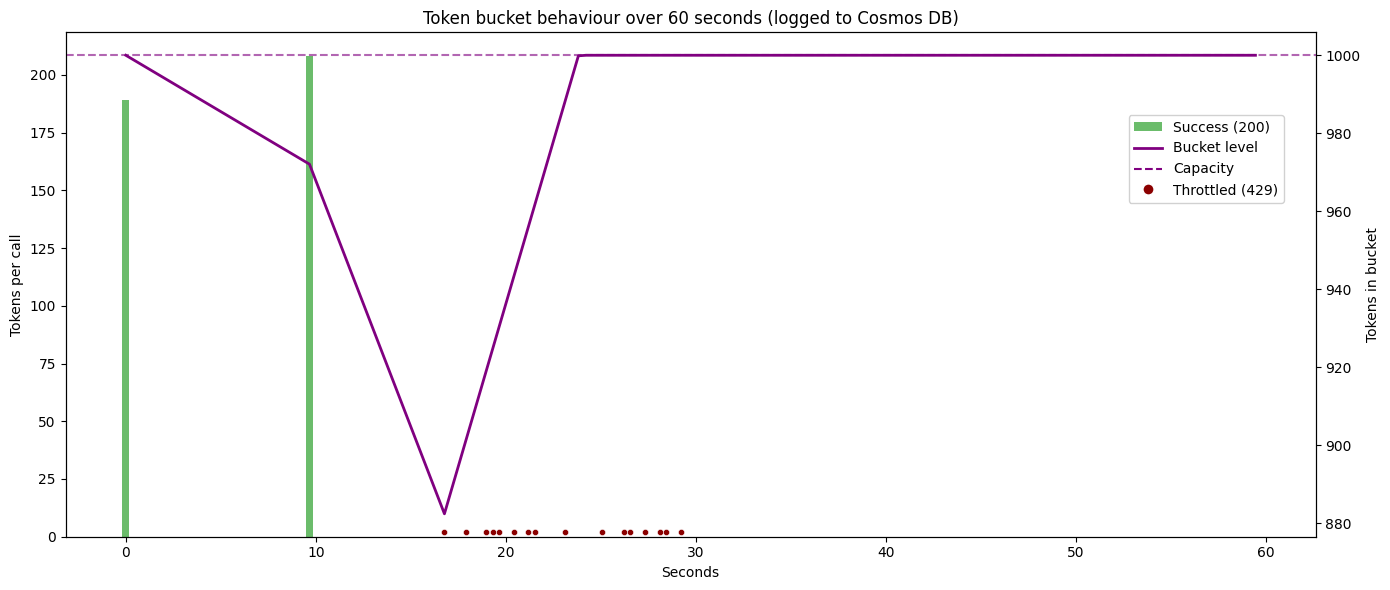

In [11]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

if 'api_runs' in locals() and api_runs:
    calls = [(t - api_runs[0][0], tokens or 0, status) for t, tokens, status in api_runs]
    capacity = 1000
    refill = capacity / 60
    bucket = capacity
    last_time = 0.0
    times, usage, status_codes, levels = [], [], [], []

    for call_time, tokens, status in calls:
        bucket = min(capacity, bucket + (call_time - last_time) * refill)
        levels.append(bucket)
        times.append(call_time)
        usage.append(tokens)
        status_codes.append(status)
        bucket = max(0, bucket - tokens)
        last_time = call_time

    colors = ['tab:green' if code == 200 else 'tab:red' if code == 429 else 'tab:orange' for code in status_codes]
    fig, ax1 = plt.subplots(figsize=(14, 6))
    ax2 = ax1.twinx()

    ax1.bar(times, usage, color=colors, width=0.35, alpha=0.7)
    ax2.plot(times, levels, color='purple', linewidth=2)
    ax2.axhline(capacity, color='purple', linestyle='--', alpha=0.6)

    throttled_times = [t for t, code in zip(times, status_codes) if code == 429]
    throttled_usage = [u for u, code in zip(usage, status_codes) if code == 429]
    if throttled_times:
        max_usage = max(usage) if usage else 0
        throttled_marker_heights = [u + max_usage * 0.01 for u in throttled_usage]
        ax1.scatter(throttled_times, throttled_marker_heights, marker='o', s=20, color='darkred', edgecolors='white', linewidth=0.4, zorder=6)

    ax1.set_xlabel('Seconds')
    ax1.set_ylabel('Tokens per call')
    ax2.set_ylabel('Tokens in bucket')
    ax1.set_title('Token bucket behaviour over 60 seconds (logged to Cosmos DB)')

    legend_items = [
        Patch(facecolor='tab:green', alpha=0.7, label='Success (200)'),
        Line2D([0], [0], color='purple', linewidth=2, label='Bucket level'),
        Line2D([0], [0], color='purple', linestyle='--', label='Capacity'),
        Line2D([0], [0], marker='o', color='darkred', markersize=8, linestyle='None',
                markerfacecolor='darkred', markeredgecolor='white', label='Throttled (429)')
    ]
    ax1.legend(handles=legend_items, loc='upper right', bbox_to_anchor=(0.98, 0.85), framealpha=0.9)

    success = sum(code == 200 for code in status_codes)
    throttled = sum(code == 429 for code in status_codes)
    print(f"Calls: {len(status_codes)} | Success: {success} | 429s: {throttled}")
    plt.tight_layout()
    plt.show()
else:
    print('Run the rate limit test first to capture api_runs data.')

<a id='query-throttled'></a>
### 🔍 Query Throttled Events from Cosmos DB

Retrieve all throttled (429) events that were logged during the rate limit test.

In [ ]:
# Query throttled events from Cosmos DB
query = """
SELECT c.id, c.productName, c.model, c.statusCode, c.isThrottled, 
       c.consumedTokens, c.remainingTokens, c.timestamp
FROM c 
WHERE c.isThrottled = true
ORDER BY c.timestamp DESC
"""

try:
    items = list(container.query_items(
        query=query,
        enable_cross_partition_query=True
    ))
    
    utils.print_ok(f"Found {len(items)} throttled events in Cosmos DB")
    print()
    
    for item in items[:10]:  # Show first 10
        print(f"⛔ ID: {item['id'][:25]}...")
        print(f"   Product: {item['productName']} | Model: {item['model']}")
        print(f"   Status: {item['statusCode']} | Consumed: {item.get('consumedTokens', 'N/A')} | Remaining: {item.get('remainingTokens', 'N/A')}")
        print(f"   Timestamp: {item['timestamp']}")
        print()
        
except Exception as e:
    utils.print_error(f"Error querying throttled events: {e}")

<a id='summary-status'></a>
### 📊 Summary: Success vs Throttled by Product

Aggregate telemetry to see success and failure rates per product.

In [ ]:
# Aggregate success vs throttled by product
query = """
SELECT 
    c.productName,
    c.statusCode,
    COUNT(1) as requestCount,
    SUM(StringToNumber(c.totalTokens)) as totalTokens
FROM c
GROUP BY c.productName, c.statusCode
"""

try:
    items = list(container.query_items(
        query=query,
        enable_cross_partition_query=True
    ))
    
    utils.print_ok(f"Telemetry summary by product and status:")
    print()
    
    # Group by product
    products = {}
    for item in items:
        product = item['productName']
        if product not in products:
            products[product] = {'200': 0, '429': 0, 'tokens': 0}
        
        status = item['statusCode']
        count = item['requestCount']
        tokens = item.get('totalTokens', 0) or 0
        
        if status == '200':
            products[product]['200'] = count
            products[product]['tokens'] = tokens
        elif status == '429':
            products[product]['429'] = count
    
    for product, stats in products.items():
        total = stats['200'] + stats['429']
        success_rate = (stats['200'] / total * 100) if total > 0 else 0
        print(f"📦 Product: {product}")
        print(f"   ✅ Success (200): {stats['200']} | ⛔ Throttled (429): {stats['429']}")
        print(f"   📊 Success Rate: {success_rate:.1f}%")
        print(f"   🔢 Total Tokens: {stats['tokens']:,}")
        print()
        
except Exception as e:
    utils.print_error(f"Error querying summary: {e}")

<a id='4'></a>
### 4️⃣ Define AI usage telemetry record structure

Create a sample AI usage telemetry record following the schema defined in `src/usage-reports/usage-record.json`.

In [ ]:
def create_usage_record(
    product_name: str,
    model: str,
    prompt_tokens: int,
    response_tokens: int,
    gateway_name: str = "apim-gateway.azure-api.net",
    gateway_region: str = "Sweden Central",
    operation_name: str = "Creates a completion for the chat message",
    backend_id: str = "openai-backend-1",
    route_location: str = "swedencentral",
    route_name: str = "SwedenCentral",
    deployment_name: str = "chat"
) -> dict:
    """
    Create an AI usage telemetry record following the standard schema.
    
    Args:
        product_name: APIM product name (partition key)
        model: Model name (e.g., gpt-4, gpt-35-turbo)
        prompt_tokens: Number of prompt tokens consumed
        response_tokens: Number of response tokens generated
        gateway_name: APIM gateway hostname
        gateway_region: Region of the gateway
        operation_name: API operation name
        backend_id: Backend identifier
        route_location: Backend route location
        route_name: Backend route name
        deployment_name: Model deployment name
    
    Returns:
        dict: AI usage telemetry record
    """
    total_tokens = prompt_tokens + response_tokens
    current_time = datetime.utcnow()
    
    return {
        "id": f"chatcmpl-{uuid.uuid4().hex[:24]}",
        "timestamp": current_time.strftime("%m/%d/%Y %I:%M:%S %p"),
        "appId": str(uuid.uuid4()),
        "subscriptionId": "master",
        "productName": product_name,  # Partition key
        "targetService": "chat.completion",
        "model": model,
        "gatewayName": gateway_name,
        "gatewayRegion": gateway_region,
        "aiGatewayId": "managed",
        "RequestIp": "10.0.0.1",
        "operationName": operation_name,
        "sessionId": "NA",
        "endUserId": "NA",
        "backendId": backend_id,
        "routeLocation": route_location,
        "routeName": route_name,
        "deploymentName": deployment_name,
        "promptTokens": str(prompt_tokens),
        "responseTokens": str(response_tokens),
        "totalTokens": str(total_tokens),
        "EventProcessedUtcTime": current_time.isoformat() + "Z",
        "PartitionId": 1,
        "EventEnqueuedUtcTime": current_time.isoformat() + "Z"
    }

# Create a sample record
sample_record = create_usage_record(
    product_name="AI-CRM-SupportAgent",
    model="gpt-4",
    prompt_tokens=1500,
    response_tokens=500
)

utils.print_info("Sample AI usage telemetry record:")
print(json.dumps(sample_record, indent=2))

<a id='5'></a>
### 5️⃣ Push single telemetry record to Cosmos DB

Insert a single AI usage telemetry record into the `ai-usage-container`.

In [ ]:
try:
    # Create the item in Cosmos DB
    response = container.create_item(body=sample_record)
    
    utils.print_ok(f"Successfully inserted record with id: {response['id']}")
    utils.print_info(f"Product Name (partition key): {response['productName']}")
    utils.print_info(f"Model: {response['model']}")
    utils.print_info(f"Total Tokens: {response['totalTokens']}")
    
except exceptions.CosmosResourceExistsError:
    utils.print_warning(f"Record with id {sample_record['id']} already exists.")
except exceptions.CosmosHttpResponseError as e:
    utils.print_error(f"Failed to insert record: {e.message}")
except Exception as e:
    utils.print_error(f"Error inserting record: {e}")

<a id='6'></a>
### 6️⃣ Push multiple telemetry records (batch simulation)

Simulate multiple AI API calls and push the telemetry records to Cosmos DB.

In [ ]:
import random
import time

# Configuration for batch simulation
batch_size = 10
product_names = ["AI-CRM-SupportAgent", "AI-HR-Assistant", "AI-Retail-Chatbot"]
models = ["gpt-4", "gpt-35-turbo", "gpt-4-turbo"]

utils.print_info(f"Inserting {batch_size} telemetry records...")

inserted_count = 0
failed_count = 0

for i in range(batch_size):
    # Generate random usage data
    record = create_usage_record(
        product_name=random.choice(product_names),
        model=random.choice(models),
        prompt_tokens=random.randint(100, 5000),
        response_tokens=random.randint(50, 2000),
        backend_id=f"openai-backend-{random.randint(1, 3)}",
        route_location=random.choice(["swedencentral", "eastus", "westeurope"]),
        route_name=random.choice(["SwedenCentral", "EastUS", "WestEurope"])
    )
    
    try:
        response = container.create_item(body=record)
        inserted_count += 1
        print(f"✅ [{i+1}/{batch_size}] Inserted: {record['productName']} | {record['model']} | {record['totalTokens']} tokens")
    except Exception as e:
        failed_count += 1
        print(f"❌ [{i+1}/{batch_size}] Failed: {e}")
    
    time.sleep(0.1)  # Small delay between inserts

print()
utils.print_ok(f"Batch complete: {inserted_count} inserted, {failed_count} failed")

<a id='7'></a>
### 7️⃣ Query telemetry records from Cosmos DB

Query the inserted telemetry records to verify the data.

In [ ]:
# Query to get recent records
query = "SELECT TOP 10 c.id, c.productName, c.model, c.promptTokens, c.responseTokens, c.totalTokens, c.timestamp FROM c ORDER BY c.timestamp DESC"

try:
    items = list(container.query_items(
        query=query,
        enable_cross_partition_query=True
    ))
    
    utils.print_ok(f"Retrieved {len(items)} records from Cosmos DB")
    print()
    
    # Display records in a formatted way
    for item in items:
        print(f"📊 ID: {item['id'][:20]}...")
        print(f"   Product: {item['productName']}")
        print(f"   Model: {item['model']}")
        print(f"   Tokens: {item['promptTokens']} prompt + {item['responseTokens']} response = {item['totalTokens']} total")
        print(f"   Timestamp: {item['timestamp']}")
        print()
        
except exceptions.CosmosHttpResponseError as e:
    utils.print_error(f"Failed to query records: {e.message}")
except Exception as e:
    utils.print_error(f"Error querying records: {e}")

<a id='8'></a>
### 8️⃣ Aggregate telemetry by product

Query aggregated token usage by product name.

In [ ]:
# Query to aggregate by product
query = """
SELECT 
    c.productName,
    COUNT(1) as requestCount,
    SUM(StringToNumber(c.totalTokens)) as totalTokens,
    SUM(StringToNumber(c.promptTokens)) as totalPromptTokens,
    SUM(StringToNumber(c.responseTokens)) as totalResponseTokens
FROM c
GROUP BY c.productName
"""

try:
    items = list(container.query_items(
        query=query,
        enable_cross_partition_query=True
    ))
    
    utils.print_ok(f"Aggregated usage by product:")
    print()
    
    for item in items:
        print(f"📦 Product: {item['productName']}")
        print(f"   Requests: {item['requestCount']}")
        print(f"   Prompt Tokens: {item.get('totalPromptTokens', 'N/A'):,}")
        print(f"   Response Tokens: {item.get('totalResponseTokens', 'N/A'):,}")
        print(f"   Total Tokens: {item.get('totalTokens', 'N/A'):,}")
        print()
        
except exceptions.CosmosHttpResponseError as e:
    utils.print_error(f"Failed to query aggregated records: {e.message}")
except Exception as e:
    utils.print_error(f"Error querying aggregated records: {e}")

<a id='9'></a>
### 9️⃣ Aggregate telemetry by model

Query aggregated token usage by model.

In [ ]:
# Query to aggregate by model
query = """
SELECT 
    c.model,
    COUNT(1) as requestCount,
    SUM(StringToNumber(c.totalTokens)) as totalTokens
FROM c
GROUP BY c.model
"""

try:
    items = list(container.query_items(
        query=query,
        enable_cross_partition_query=True
    ))
    
    utils.print_ok(f"Aggregated usage by model:")
    print()
    
    for item in items:
        print(f"🤖 Model: {item['model']}")
        print(f"   Requests: {item['requestCount']}")
        print(f"   Total Tokens: {item.get('totalTokens', 'N/A'):,}")
        print()
        
except exceptions.CosmosHttpResponseError as e:
    utils.print_error(f"Failed to query aggregated records: {e.message}")
except Exception as e:
    utils.print_error(f"Error querying aggregated records: {e}")

<a id='cleanup'></a>
### 🧹 Optional: Clean up test records

Delete the test records created during this notebook session. **Use with caution!**

In [ ]:
# WARNING: This will delete records! Uncomment to use.

# cleanup_products = ["AI-CRM-SupportAgent", "AI-HR-Assistant", "AI-Retail-Chatbot"]
# deleted_count = 0

# for product_name in cleanup_products:
#     query = f"SELECT c.id FROM c WHERE c.productName = '{product_name}'"
#     items = list(container.query_items(query=query, enable_cross_partition_query=True))
    
#     for item in items:
#         try:
#             container.delete_item(item=item['id'], partition_key=product_name)
#             deleted_count += 1
#         except Exception as e:
#             utils.print_error(f"Failed to delete {item['id']}: {e}")

# utils.print_ok(f"Deleted {deleted_count} test records")

utils.print_info("Cleanup code is commented out. Uncomment to delete test records.")

---

## 🎯 Multi-Modal Use Case Testing with Model Restrictions

This section demonstrates:
1. **Creating APIM Products** with different model restrictions (simulating use-case-specific governance)
2. **Multi-modal inputs**: Testing with text prompts, images (PNG), and text documents
3. **Use Case Isolation**: Each product only has access to specific models

### Use Case Scenarios

| Use Case | Product Name | Allowed Models | Description |
|----------|--------------|----------------|-------------|
| **Vision Analytics** | `UC-VisionAnalytics` | `gpt-4o`, `gpt-4o-mini` | Image analysis, document OCR |
| **Text Processing** | `UC-TextProcessing` | `DeepSeek-R1`, `Phi-4` | Text-only tasks, no vision |

<a id='create-products'></a>
### 🏭 Step 1: Create APIM Products for Each Use Case

This cell creates two new APIM products with different model access policies.
Each product will have its own subscription key, simulating different teams/use cases.

> **Note**: This requires APIM Contributor permissions. The products will be created with:
> - A subscription key for API access
> - A policy that restricts which models can be called

In [9]:
# Define the two use cases with their model restrictions
use_cases = {
    "UC-VisionAnalytics": {
        "display_name": "Vision Analytics Use Case",
        "description": "Product for image analysis and document OCR. Allows vision-capable models only.",
        "allowed_models": ["gpt-4o", "gpt-4o-mini"],  # Vision-capable models
        "terms": "This product is restricted to vision-capable AI models for image and document analysis."
    },
    "UC-TextProcessing": {
        "display_name": "Text Processing Use Case", 
        "description": "Product for text-only tasks. No vision capabilities.",
        "allowed_models": ["DeepSeek-R1", "Phi-4"],  # Text-only or vision models
        "terms": "This product is restricted to text-only AI models. Vision inputs will be rejected."
    }
}

# Store subscription keys for each use case
use_case_keys = {}

utils.print_info("Use cases defined:")
for uc_name, uc_config in use_cases.items():
    print(f"  📦 {uc_name}: {uc_config['allowed_models']}")

👉🏽 Use cases defined:
  📦 UC-VisionAnalytics: ['gpt-4o', 'gpt-4o-mini']
  📦 UC-TextProcessing: ['DeepSeek-R1', 'Phi-4']


In [13]:
# Create APIM Products for each use case
# This cell uses Azure CLI/REST API to create products and subscriptions in APIM

apim_name = apimClientTool.apim_resource_name
api_name = apimClientTool.api_id.split('/')[-1] if '/' in apimClientTool.api_id else apimClientTool.api_id

for uc_name, uc_config in use_cases.items():
    utils.print_info(f"Creating product: {uc_name}...")
    
    # 1. Create the product
    create_product_cmd = f"""az apim product create \
        --resource-group {governance_hub_resource_group} \
        --service-name {apim_name} \
        --product-id {uc_name} \
        --product-name "{uc_config['display_name']}" \
        --description "{uc_config['description']}" \
        --legal-terms "{uc_config['terms']}" \
        --subscription-required true \
        --approval-required false \
        --state published"""
    
    output = utils.run(create_product_cmd, 
                       f"Created product {uc_name}", 
                       f"Failed to create product {uc_name} (may already exist)")
    
    # 2. Add the API to the product
    add_api_cmd = f"""az apim product api add \
        --resource-group {governance_hub_resource_group} \
        --service-name {apim_name} \
        --product-id {uc_name} \
        --api-id {api_name}"""
    
    utils.run(add_api_cmd, 
              f"Added API to {uc_name}", 
              f"Failed to add API (may already be added)")
    
    # 3. Create subscription using REST API (more reliable than broken az apim subscription)
    sub_name = f"sub-{uc_name}-notebook"
    sub_resource_id = f"/subscriptions/{subscription_id}/resourceGroups/{governance_hub_resource_group}/providers/Microsoft.ApiManagement/service/{apim_name}/subscriptions/{sub_name}"
    
    create_sub_body = {
        "properties": {
            "displayName": f"Notebook Test - {uc_name}",
            "scope": f"/products/{uc_name}",
            "state": "active"
        }
    }
    
    create_sub_cmd = f"""az rest --method PUT \
        --uri "https://management.azure.com{sub_resource_id}?api-version=2022-08-01" \
        --body '{json.dumps(create_sub_body)}'"""
    
    sub_output = utils.run(create_sub_cmd, 
                           f"Created subscription for {uc_name}", 
                           f"Failed to create subscription (may already exist)")
    
    # 4. Get the subscription key using REST API
    get_key_cmd = f"""az rest --method POST \
        --uri "https://management.azure.com{sub_resource_id}/listSecrets?api-version=2022-08-01" \
        --query primaryKey -o tsv"""
    
    key_output = utils.run(get_key_cmd, "Got subscription key", "Failed to get key")
    if key_output.success and key_output.text.strip():
        use_case_keys[uc_name] = key_output.text.strip()
        utils.print_ok(f"✅ {uc_name} ready with key: {use_case_keys[uc_name][:8]}...")
    
    print()

utils.print_ok(f"Created {len(use_case_keys)} use case products with subscriptions")

👉🏽 Creating product: UC-VisionAnalytics...
⚙️ Running: az apim product create         --resource-group rg-ai-hub-citadel-dev-01         --service-name apim-7za43v3vyyahe         --product-id UC-VisionAnalytics         --product-name "Vision Analytics Use Case"         --description "Product for image analysis and document OCR. Allows vision-capable models only."         --legal-terms "This product is restricted to vision-capable AI models for image and document analysis."         --subscription-required true         --approval-required false         --state published 
✅ Created product UC-VisionAnalytics ⌚ 09:07:43.298833 :0s]
⚙️ Running: az apim product api add         --resource-group rg-ai-hub-citadel-dev-01         --service-name apim-7za43v3vyyahe         --product-id UC-VisionAnalytics         --api-id universal-llm-api 
✅ Added API to UC-VisionAnalytics ⌚ 09:07:44.457002 :1s]
⚙️ Running: az rest --method PUT         --uri "https://management.azure.com/subscriptions/fdb7813e-e1a5

<a id='model-policy'></a>
### 🔒 Step 2: Apply Model Restriction Policies (Optional)

To enforce model restrictions at the APIM level, you would need to add a policy to each product.
The policy below validates the requested model against the allowed list.

> **Note**: This is a sample policy XML. In production, you would apply this via Bicep or Azure CLI.
> The policy intercepts requests and checks the `model` field in the JSON body.

In [25]:
# Sample policy XML for model restriction
# This policy validates the model in the request body against an allowed list

def generate_model_restriction_policy(allowed_models: list) -> str:
    """Generate APIM policy XML to restrict models for a product."""
    # Build the condition for allowed models
    # Must use (string)context.Variables["model"] to access the variable in the condition
    # Use &quot; for double quotes in C# strings inside XML attributes
    models_check = " || ".join([f'(string)context.Variables[&quot;model&quot;] == &quot;{m}&quot;' for m in allowed_models])
    allowed_models_str = ', '.join(allowed_models)
    
    # Note: We use &lt; and &gt; to escape angle brackets in C# generics
    # and &quot; to escape double quotes in C# string literals
    # This is required because these appear inside XML attribute values
    return f'''<policies>
    <inbound>
        <base />
        <set-variable name="requestBody" value="@(context.Request.Body.As&lt;JObject&gt;(preserveContent: true))" />
        <set-variable name="model" value="@((string)((JObject)context.Variables[&quot;requestBody&quot;])[&quot;model&quot;])" />
        <choose>
            <when condition="@(!({models_check}))">
                <return-response>
                    <set-status code="403" reason="Model Not Allowed" />
                    <set-header name="Content-Type" exists-action="override">
                        <value>application/json</value>
                    </set-header>
                    <set-body>@{{
                        var model = (string)context.Variables["model"];
                        return new JObject(
                            new JProperty("error", new JObject(
                                new JProperty("code", "model_not_allowed"),
                                new JProperty("message", $"Model '{{model}}' is not allowed for this product. Allowed models: {allowed_models_str}")
                            ))
                        ).ToString();
                    }}</set-body>
                </return-response>
            </when>
        </choose>
    </inbound>
    <backend>
        <base />
    </backend>
    <outbound>
        <base />
    </outbound>
</policies>'''

# Display sample policies for each use case
for uc_name, uc_config in use_cases.items():
    print(f"📋 Policy for {uc_name}:")
    print(f"   Allowed models: {uc_config['allowed_models']}")
    print()

utils.print_info("To apply these policies, run the next cell.")

📋 Policy for UC-VisionAnalytics:
   Allowed models: ['gpt-4o', 'gpt-4o-mini']

📋 Policy for UC-TextProcessing:
   Allowed models: ['DeepSeek-R1', 'Phi-4']

👉🏽 To apply these policies, run the next cell.


In [26]:
# Apply model restriction policies to each product
# This cell uses the Azure REST API to set product-level policies

import tempfile
import os

for uc_name, uc_config in use_cases.items():
    utils.print_info(f"Applying model restriction policy to: {uc_name}...")
    
    # Generate the policy XML for this use case
    policy_xml = generate_model_restriction_policy(uc_config['allowed_models'])
    
    # Policy resource ID
    policy_resource_id = f"/subscriptions/{subscription_id}/resourceGroups/{governance_hub_resource_group}/providers/Microsoft.ApiManagement/service/{apim_name}/products/{uc_name}/policies/policy"
    
    # Prepare the policy body for REST API
    policy_body = {
        "properties": {
            "format": "xml",
            "value": policy_xml
        }
    }
    
    # Write the body to a temp file to avoid shell escaping issues
    temp_file = f"/tmp/policy_{uc_name}.json"
    with open(temp_file, 'w') as f:
        json.dump(policy_body, f)
    
    # Use az rest with @file syntax to avoid shell escaping issues
    apply_policy_cmd = f'''az rest --method PUT \
        --uri "https://management.azure.com{policy_resource_id}?api-version=2022-08-01" \
        --body @{temp_file}'''
    
    output = utils.run(apply_policy_cmd,
                       f"✅ Applied policy to {uc_name} - Allowed models: {uc_config['allowed_models']}",
                       f"❌ Failed to apply policy to {uc_name}")
    
    if output.success:
        utils.print_ok(f"   Models allowed: {', '.join(uc_config['allowed_models'])}")
    else:
        # Show error details
        utils.print_warning(f"   Error: {output.text[:200] if output.text else 'Unknown error'}...")
    
    # Clean up temp file
    if os.path.exists(temp_file):
        os.remove(temp_file)
    
    print()

utils.print_ok("Model restriction policies applied to all use case products")

👉🏽 Applying model restriction policy to: UC-VisionAnalytics...
⚙️ Running: az rest --method PUT         --uri "https://management.azure.com/subscriptions/fdb7813e-e1a5-402e-a952-04c7b82e9f5d/resourceGroups/rg-ai-hub-citadel-dev-01/providers/Microsoft.ApiManagement/service/apim-7za43v3vyyahe/products/UC-VisionAnalytics/policies/policy?api-version=2022-08-01"         --body @/tmp/policy_UC-VisionAnalytics.json 
✅ ✅ Applied policy to UC-VisionAnalytics - Allowed models: ['gpt-4o', 'gpt-4o-mini'] ⌚ 09:30:57.348151 :1s]
✅    Models allowed: gpt-4o, gpt-4o-mini ⌚ 09:30:57.348521 

👉🏽 Applying model restriction policy to: UC-TextProcessing...
⚙️ Running: az rest --method PUT         --uri "https://management.azure.com/subscriptions/fdb7813e-e1a5-402e-a952-04c7b82e9f5d/resourceGroups/rg-ai-hub-citadel-dev-01/providers/Microsoft.ApiManagement/service/apim-7za43v3vyyahe/products/UC-TextProcessing/policies/policy?api-version=2022-08-01"         --body @/tmp/policy_UC-TextProcessing.json 
✅ ✅ Appl

---

## 📸 Multi-Modal Input Testing

Now we'll test different input types:
- **Text prompts** - Standard chat completions
- **Images (PNG/JPG)** - Vision analysis with base64 encoding
- **Text documents** - Document content extraction and analysis

<a id='helper-functions'></a>
### 🔧 Helper Functions for Multi-Modal Inputs

Functions to encode images and documents for API calls.

In [28]:
!pip install ipywidgets --quiet

In [29]:
import base64
from pathlib import Path
import ipywidgets as widgets
from IPython.display import display, Image as IPImage, clear_output

def encode_image_to_base64(image_path: str) -> str:
    """Encode an image file to base64 string."""
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

def get_image_media_type(image_path: str) -> str:
    """Get the media type based on file extension."""
    ext = Path(image_path).suffix.lower()
    media_types = {
        '.png': 'image/png',
        '.jpg': 'image/jpeg',
        '.jpeg': 'image/jpeg',
        '.gif': 'image/gif',
        '.webp': 'image/webp'
    }
    return media_types.get(ext, 'image/png')

def read_text_document(file_path: str) -> str:
    """Read content from a text document."""
    with open(file_path, 'r', encoding='utf-8') as f:
        return f.read()

def create_vision_message(prompt: str, image_path: str = None, image_url: str = None) -> dict:
    """
    Create a message with text and optional image for vision models.
    
    Args:
        prompt: The text prompt
        image_path: Local path to an image file (will be base64 encoded)
        image_url: URL to an image (alternative to local path)
    
    Returns:
        Message dict formatted for vision API
    """
    content = []
    
    # Add text content
    content.append({
        "type": "text",
        "text": prompt
    })
    
    # Add image content if provided
    if image_path:
        base64_image = encode_image_to_base64(image_path)
        media_type = get_image_media_type(image_path)
        content.append({
            "type": "image_url",
            "image_url": {
                "url": f"data:{media_type};base64,{base64_image}"
            }
        })
    elif image_url:
        content.append({
            "type": "image_url",
            "image_url": {
                "url": image_url
            }
        })
    
    return {"role": "user", "content": content}

def create_document_message(prompt: str, document_path: str) -> dict:
    """
    Create a message with text document content embedded in the prompt.
    
    Args:
        prompt: The analysis prompt
        document_path: Path to the text document
    
    Returns:
        Message dict with document content
    """
    doc_content = read_text_document(document_path)
    full_prompt = f"{prompt}\n\n---\nDocument Content:\n---\n{doc_content}"
    
    return {"role": "user", "content": full_prompt}

utils.print_ok("Multi-modal helper functions defined")

✅ Multi-modal helper functions defined ⌚ 09:39:03.721686 


<a id='sample-files'></a>
### 📁 Create Sample Test Files

Create sample image and text files for testing (you can replace these with your own files).

In [30]:
# Create a sample text document for testing
sample_doc_path = "/tmp/sample_document.txt"
sample_doc_content = """
QUARTERLY BUSINESS REPORT - Q4 2024
=====================================

Executive Summary:
The company achieved record revenue of $15.2M in Q4, representing a 23% increase YoY.
Key highlights include:
- Customer acquisition up 45% 
- Churn rate reduced to 2.1%
- New enterprise contracts: 12

Regional Performance:
- North America: $8.5M (56% of total)
- Europe: $4.2M (28% of total)  
- Asia Pacific: $2.5M (16% of total)

Strategic Initiatives:
1. AI-powered customer support launched in October
2. Mobile app redesign completed
3. Partnership with TechCorp announced

Outlook for Q1 2025:
We project continued growth with revenue target of $16.5M.
Key focus areas: international expansion, product innovation.
"""

with open(sample_doc_path, 'w') as f:
    f.write(sample_doc_content)

utils.print_ok(f"Created sample document: {sample_doc_path}")

# For images, you can either:
# 1. Upload your own PNG/JPG files
# 2. Use a URL to a public image
# 3. Create a simple test image programmatically

sample_image_url = "https://upload.wikimedia.org/wikipedia/commons/thumb/4/47/PNG_transparency_demonstration_1.png/300px-PNG_transparency_demonstration_1.png"
utils.print_info(f"Sample image URL: {sample_image_url}")

# Placeholder for local image path - update this to your own image
sample_image_path = None  # Set to a local path like "/tmp/test_image.png" if you have one
utils.print_info("Set 'sample_image_path' to a local PNG/JPG file path to test with local images")

✅ Created sample document: /tmp/sample_document.txt ⌚ 09:39:16.399605 
👉🏽 Sample image URL: https://upload.wikimedia.org/wikipedia/commons/thumb/4/47/PNG_transparency_demonstration_1.png/300px-PNG_transparency_demonstration_1.png
👉🏽 Set 'sample_image_path' to a local PNG/JPG file path to test with local images


<a id='interactive-test'></a>
### 🎮 Interactive Multi-Modal Testing Interface

Use this interactive interface to:
1. Select a **Use Case** (Vision Analytics or Text Processing)
2. Choose **Input Type** (Text only, Image + Text, or Document + Text)
3. Enter your **Prompt**
4. Upload files or use sample data
5. Send the request and see results + telemetry

In [31]:
# Interactive testing function
def test_use_case(
    use_case: str,
    input_type: str,
    prompt: str,
    image_path: str = None,
    image_url: str = None,
    document_path: str = None,
    log_to_cosmos: bool = True
):
    """
    Test a specific use case with various input types.
    
    Args:
        use_case: "UC-VisionAnalytics" or "UC-TextProcessing"
        input_type: "text", "image", or "document"
        prompt: The user prompt
        image_path: Path to local image file (for image input)
        image_url: URL to image (alternative to local path)
        document_path: Path to text document (for document input)
        log_to_cosmos: Whether to log telemetry to Cosmos DB
    """
    print(f"{'='*60}")
    print(f"🎯 USE CASE: {use_case}")
    print(f"📝 INPUT TYPE: {input_type}")
    print(f"{'='*60}\n")
    
    # Get the appropriate API key and model
    uc_config = use_cases.get(use_case)
    if not uc_config:
        utils.print_error(f"Unknown use case: {use_case}")
        return
    
    # Use the use-case specific key if available, otherwise fall back to default
    api_key_to_use = use_case_keys.get(use_case, api_key)
    model_to_use = uc_config["allowed_models"][0]  # Use first allowed model
    
    utils.print_info(f"Model: {model_to_use}")
    utils.print_info(f"Allowed models for this use case: {uc_config['allowed_models']}")
    print()
    
    # Build the message based on input type
    messages_list = [
        {"role": "system", "content": "You are a helpful AI assistant. Be concise in your responses."}
    ]
    
    if input_type == "text":
        messages_list.append({"role": "user", "content": prompt})
        
    elif input_type == "image":
        if image_path:
            messages_list.append(create_vision_message(prompt, image_path=image_path))
            utils.print_info(f"Image: {image_path}")
        elif image_url:
            messages_list.append(create_vision_message(prompt, image_url=image_url))
            utils.print_info(f"Image URL: {image_url[:50]}...")
        else:
            utils.print_error("No image provided for image input type")
            return
            
    elif input_type == "document":
        if document_path:
            messages_list.append(create_document_message(prompt, document_path))
            utils.print_info(f"Document: {document_path}")
        else:
            utils.print_error("No document provided for document input type")
            return
    
    # Prepare the request
    request_body = {
        "model": model_to_use,
        "messages": messages_list,
        "max_tokens": 500
    }
    
    print(f"\n📤 Sending request to: {chat_completions_url}")
    print(f"   Prompt: {prompt[:100]}{'...' if len(prompt) > 100 else ''}\n")
    
    # Make the API call
    start_time = time.time()
    response = requests.post(
        chat_completions_url, 
        headers={'api-key': api_key_to_use, 'Content-Type': 'application/json'}, 
        json=request_body
    )
    elapsed = time.time() - start_time
    
    # Process response
    print(f"⏱️ Response time: {elapsed:.2f}s")
    print(f"📊 Status: {response.status_code}")
    
    if response.status_code == 200:
        data = response.json()
        content = data.get("choices", [{}])[0].get("message", {}).get("content", "")
        usage = data.get("usage", {})
        
        print(f"\n💬 RESPONSE:")
        print(f"{'─'*40}")
        print(content)
        print(f"{'─'*40}")
        print(f"\n📈 Token Usage:")
        print(f"   Prompt: {usage.get('prompt_tokens', 'N/A')}")
        print(f"   Completion: {usage.get('completion_tokens', 'N/A')}")
        print(f"   Total: {usage.get('total_tokens', 'N/A')}")
        print(f"   Region: {response.headers.get('x-ms-region', 'N/A')}")
        
        # Log to Cosmos DB
        if log_to_cosmos:
            record = log_telemetry_to_cosmos(response, data, model_to_use, use_case, is_throttled=False)
            if record:
                utils.print_ok(f"\n✅ Telemetry logged to Cosmos DB")
                
    elif response.status_code == 403:
        utils.print_error(f"Model not allowed for this use case!")
        print(f"   Response: {response.text}")
        
        if log_to_cosmos:
            log_telemetry_to_cosmos(response, {}, model_to_use, use_case, is_throttled=False)
            
    elif response.status_code == 429:
        utils.print_warning("Rate limited (429)")
        
        if log_to_cosmos:
            log_telemetry_to_cosmos(response, {}, model_to_use, use_case, is_throttled=True)
    else:
        utils.print_error(f"Error: {response.text}")
    
    return response

utils.print_ok("Interactive test function defined")

✅ Interactive test function defined ⌚ 09:47:23.057203 


<a id='test-vision'></a>
### 🖼️ Test 1: Vision Analytics Use Case (Image Analysis)

Test the Vision Analytics use case with an image input.
This use case allows: `gpt-4o`, `gpt-4-turbo` (vision-capable models)

In [32]:
# Test 1: Vision Analytics with Image URL
# =========================================
# This test uses a vision-capable model to analyze an image

test_use_case(
    use_case="UC-VisionAnalytics",
    input_type="image",
    prompt="Describe what you see in this image. What colors and shapes are present?",
    image_url=sample_image_url,  # Using the sample Wikipedia PNG image
    log_to_cosmos=True
)

🎯 USE CASE: UC-VisionAnalytics
📝 INPUT TYPE: image

👉🏽 Model: gpt-4o
👉🏽 Allowed models for this use case: ['gpt-4o', 'gpt-4o-mini']

👉🏽 Image URL: https://upload.wikimedia.org/wikipedia/commons/thu...

📤 Sending request to: https://apim-7za43v3vyyahe.azure-api.net/models/chat/completions?api-version=2024-05-01-preview
   Prompt: Describe what you see in this image. What colors and shapes are present?

⏱️ Response time: 8.38s
📊 Status: 200

💬 RESPONSE:
────────────────────────────────────────
The image shows three colorful dice. The dice are shaped as cubes and have rounded edges. Each die has white dots on its faces, representing numbers. The colors of the dice are blue, green, and red. There is also a faint shadow or reflection below them in yellow. The dice are slightly transparent, giving them a glossy effect, and they seem to float or hover in the scene.
────────────────────────────────────────

📈 Token Usage:
   Prompt: 294
   Completion: 80
   Total: 374
   Region: Sweden Central

/tmp/ipykernel_12359/1600593902.py:13: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  current_time = datetime.utcnow()


✅ 
✅ Telemetry logged to Cosmos DB ⌚ 10:22:32.765672 


<Response [200]>

<a id='test-document'></a>
### 📄 Test 2: Text Processing Use Case (Document Analysis)

Test the Text Processing use case with a document input.
This use case allows: `gpt-4`, `gpt-35-turbo` (text-only models)

In [33]:
# Test 2: Text Processing with Document
# ======================================
# This test uses a text-only model to analyze a business document

test_use_case(
    use_case="UC-TextProcessing",
    input_type="document",
    prompt="Summarize this quarterly report in 3 bullet points. What are the key takeaways?",
    document_path=sample_doc_path,
    log_to_cosmos=True
)

🎯 USE CASE: UC-TextProcessing
📝 INPUT TYPE: document

👉🏽 Model: DeepSeek-R1
👉🏽 Allowed models for this use case: ['DeepSeek-R1', 'Phi-4']

👉🏽 Document: /tmp/sample_document.txt

📤 Sending request to: https://apim-7za43v3vyyahe.azure-api.net/models/chat/completions?api-version=2024-05-01-preview
   Prompt: Summarize this quarterly report in 3 bullet points. What are the key takeaways?

⏱️ Response time: 8.64s
📊 Status: 200

💬 RESPONSE:
────────────────────────────────────────
<think>
Okay, let's tackle this. The user wants a summary of the quarterly report in three bullet points with key takeaways. First, I need to parse the document content carefully.

Starting with the Executive Summary: Record revenue of $15.2M, 23% YoY growth. That's a big number, so that's definitely a key point. Then the highlights: 45% customer acquisition increase, lower churn rate at 2.1%, and 12 new enterprise contracts. These are all important metrics showing growth and customer retention.

Regional Performan

/tmp/ipykernel_12359/1600593902.py:13: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  current_time = datetime.utcnow()


✅ 
✅ Telemetry logged to Cosmos DB ⌚ 10:47:44.195333 


<Response [200]>

<a id='test-blocked'></a>
### 🚫 Test: Model Restriction Policy Enforcement

These tests demonstrate the APIM policy blocking requests when trying to use a model that is **not allowed** for the use case.

| Test | Use Case | Requested Model | Expected Result |
|------|----------|-----------------|-----------------|
| **Test A** | `UC-VisionAnalytics` | `DeepSeek-R1` ❌ | **403 Forbidden** (only gpt-4o, gpt-4o-mini allowed) |
| **Test B** | `UC-TextProcessing` | `gpt-4o` ❌ | **403 Forbidden** (only DeepSeek-R1, Phi-4 allowed) |

In [34]:
# Test A: Try to use DeepSeek-R1 with Vision Analytics product (SHOULD BE BLOCKED)
# ==================================================================================
# UC-VisionAnalytics only allows: gpt-4o, gpt-4o-mini
# Requesting DeepSeek-R1 should result in 403 Forbidden

def test_blocked_model(use_case: str, blocked_model: str, prompt: str = "Hello, can you help me?"):
    """Test that a blocked model returns 403."""
    print(f"{'='*60}")
    print(f"🚫 BLOCKED MODEL TEST")
    print(f"{'='*60}")
    print(f"   Use Case: {use_case}")
    print(f"   Attempting model: {blocked_model}")
    print(f"   Allowed models: {use_cases[use_case]['allowed_models']}")
    print(f"{'='*60}\n")
    
    api_key_to_use = use_case_keys.get(use_case, api_key)
    
    request_body = {
        "model": blocked_model,
        "messages": [
            {"role": "system", "content": "You are a helpful assistant."},
            {"role": "user", "content": prompt}
        ],
        "max_tokens": 100
    }
    
    response = requests.post(
        chat_completions_url, 
        headers={'api-key': api_key_to_use, 'Content-Type': 'application/json'}, 
        json=request_body
    )
    
    print(f"📊 Status Code: {response.status_code}")
    
    if response.status_code == 403:
        utils.print_ok("✅ Request was correctly BLOCKED by the model restriction policy!")
        try:
            error_data = response.json()
            print(f"\n📄 Error Response:")
            print(json.dumps(error_data, indent=2))
        except:
            print(f"\n📄 Response: {response.text[:500]}")
    elif response.status_code == 200:
        utils.print_error("❌ Request was NOT blocked - policy may not be applied correctly")
    else:
        utils.print_warning(f"⚠️ Unexpected status code: {response.status_code}")
        print(f"   Response: {response.text[:300]}")
    
    return response

# Test A: Vision Analytics with blocked model (DeepSeek-R1)
print("🔴 TEST A: Vision Analytics trying to use DeepSeek-R1 (not allowed)\n")
test_blocked_model("UC-VisionAnalytics", "DeepSeek-R1", "Describe the weather today.")

🔴 TEST A: Vision Analytics trying to use DeepSeek-R1 (not allowed)

🚫 BLOCKED MODEL TEST
   Use Case: UC-VisionAnalytics
   Attempting model: DeepSeek-R1
   Allowed models: ['gpt-4o', 'gpt-4o-mini']

📊 Status Code: 403
✅ ✅ Request was correctly BLOCKED by the model restriction policy! ⌚ 10:54:24.948654 

📄 Error Response:
{
  "error": {
    "code": "model_not_allowed",
    "message": "Model 'DeepSeek-R1' is not allowed for this product. Allowed models: gpt-4o, gpt-4o-mini"
  }
}


<Response [403]>

In [35]:
# Test B: Try to use gpt-4o with Text Processing product (SHOULD BE BLOCKED)
# =============================================================================
# UC-TextProcessing only allows: DeepSeek-R1, Phi-4
# Requesting gpt-4o should result in 403 Forbidden

print("🔴 TEST B: Text Processing trying to use gpt-4o (not allowed)\n")
test_blocked_model("UC-TextProcessing", "gpt-4o", "What is 2+2?")

🔴 TEST B: Text Processing trying to use gpt-4o (not allowed)

🚫 BLOCKED MODEL TEST
   Use Case: UC-TextProcessing
   Attempting model: gpt-4o
   Allowed models: ['DeepSeek-R1', 'Phi-4']

📊 Status Code: 403
✅ ✅ Request was correctly BLOCKED by the model restriction policy! ⌚ 10:54:53.603959 

📄 Error Response:
{
  "error": {
    "code": "model_not_allowed",
    "message": "Model 'gpt-4o' is not allowed for this product. Allowed models: DeepSeek-R1, Phi-4"
  }
}


<Response [403]>

<a id='test-custom'></a>
### 🧪 Test 3: Custom Test - Your Own Inputs

Use this cell to test with your own prompts, images, and documents.
Modify the parameters below to test different scenarios.

In [ ]:
# ============================================================
# CUSTOM TEST - Modify these parameters for your own testing
# ============================================================

# Choose your use case: "UC-VisionAnalytics" or "UC-TextProcessing"
CUSTOM_USE_CASE = "UC-VisionAnalytics"

# Choose input type: "text", "image", or "document"
CUSTOM_INPUT_TYPE = "text"

# Your prompt
CUSTOM_PROMPT = "What is the capital of France? Answer in one sentence."

# For image input - provide either a local path or URL
CUSTOM_IMAGE_PATH = None  # e.g., "/path/to/your/image.png"
CUSTOM_IMAGE_URL = None   # e.g., "https://example.com/image.png"

# For document input - provide a local path to a .txt file
CUSTOM_DOCUMENT_PATH = None  # e.g., "/path/to/your/document.txt"

# ============================================================
# Run the test
# ============================================================
test_use_case(
    use_case=CUSTOM_USE_CASE,
    input_type=CUSTOM_INPUT_TYPE,
    prompt=CUSTOM_PROMPT,
    image_path=CUSTOM_IMAGE_PATH,
    image_url=CUSTOM_IMAGE_URL,
    document_path=CUSTOM_DOCUMENT_PATH,
    log_to_cosmos=True
)

---

## 🎯 AI Foundry Evaluations

This section uses **Azure AI Foundry Evaluations** to assess LLM response quality:

| Evaluation | Description |
|------------|-------------|
| **Relevance** | Does the response address the user's query? |
| **Groundedness** | Is the response based on provided context (no hallucinations)? |
| **Coherence** | Is the response logical and well-structured? |
| **Fluency** | Is the response grammatically correct and readable? |
| **Content Safety** | Does the response contain harmful content? |

All evaluation scores are logged to Cosmos DB alongside the original telemetry for comprehensive observability.

> **Note**: AI Foundry evaluations require a judge model (typically GPT-4) to assess responses.

In [8]:
# Install Azure AI Evaluation SDK
%pip install -q azure-ai-evaluation

Note: you may need to restart the kernel to use updated packages.


<a id='eval-setup'></a>
### ⚙️ Initialize Evaluators

Configure the judge model and initialize the AI Foundry evaluators.

> **Requirements**: Evaluators use a GPT-4 class model as a "judge" to assess response quality.

In [9]:
# Initialize AI Foundry Evaluators - NON-LLM Based (no judge model required!)
# These evaluators compute metrics algorithmically without calling an LLM

from azure.ai.evaluation import (
    RougeScoreEvaluator,  # Text overlap - recall focused
    BleuScoreEvaluator,   # Text overlap - precision focused  
    F1ScoreEvaluator,     # Token overlap between response and ground truth
    MeteorScoreEvaluator, # Synonym-aware text similarity
    GleuScoreEvaluator,   # Sentence-level BLEU variant
)

# Initialize non-LLM evaluators (no API calls needed!)
rouge_evaluator = RougeScoreEvaluator(rouge_type="rouge1")  # Options: rouge1, rouge2, rougeL, rougeLsum
bleu_evaluator = BleuScoreEvaluator()
f1_evaluator = F1ScoreEvaluator()
meteor_evaluator = MeteorScoreEvaluator()
gleu_evaluator = GleuScoreEvaluator()

evaluators_available = True

utils.print_ok("✅ Non-LLM Evaluators initialized (no judge model required):")
utils.print_info("   - ROUGE: Measures recall of n-grams from reference text")
utils.print_info("   - BLEU: Measures precision of n-grams (translation quality)")
utils.print_info("   - F1: Token overlap between response and ground truth")
utils.print_info("   - METEOR: Synonym-aware similarity with stemming")
utils.print_info("   - GLEU: Sentence-level BLEU variant")

✅ ✅ Non-LLM Evaluators initialized (no judge model required): ⌚ 10:20:03.093932 
👉🏽    - ROUGE: Measures recall of n-grams from reference text
👉🏽    - BLEU: Measures precision of n-grams (translation quality)
👉🏽    - F1: Token overlap between response and ground truth
👉🏽    - METEOR: Synonym-aware similarity with stemming
👉🏽    - GLEU: Sentence-level BLEU variant


In [10]:
def evaluate_response(response: str, ground_truth: str = None) -> dict:
    """
    Evaluate an LLM response using non-LLM evaluators (no judge model needed).
    
    These evaluators compare the response against a ground truth/reference answer.
    They're ideal for tasks where you have expected answers (Q&A, summarization, etc.)
    
    Args:
        response: The LLM's response to evaluate
        ground_truth: The expected/reference answer to compare against
    
    Returns:
        dict: Evaluation scores (0-1 scale for most metrics)
    """
    scores = {
        "rouge1_precision": None,
        "rouge1_recall": None,
        "rouge1_f1": None,
        "bleu": None,
        "f1": None,
        "meteor": None,
        "gleu": None
    }
    
    if not ground_truth:
        print("  ⚠️ No ground truth provided - non-LLM evaluators require a reference answer")
        return scores
    
    print("  🎯 Running non-LLM evaluations (comparing to ground truth)...")
    
    # ROUGE: Recall-Oriented Understudy for Gisting Evaluation
    try:
        result = rouge_evaluator(response=response, ground_truth=ground_truth)
        scores["rouge1_precision"] = result.get("rouge1_precision")
        scores["rouge1_recall"] = result.get("rouge1_recall")
        scores["rouge1_f1"] = result.get("rouge1_f1")
        print(f"     📊 ROUGE-1: P={scores['rouge1_precision']:.3f} R={scores['rouge1_recall']:.3f} F1={scores['rouge1_f1']:.3f}")
    except Exception as e:
        print(f"     ⚠️ ROUGE failed: {str(e)[:80]}")
    
    # BLEU: Bilingual Evaluation Understudy (precision focused)
    try:
        result = bleu_evaluator(response=response, ground_truth=ground_truth)
        scores["bleu"] = result.get("bleu_score")
        print(f"     📊 BLEU: {scores['bleu']:.3f}")
    except Exception as e:
        print(f"     ⚠️ BLEU failed: {str(e)[:80]}")
    
    # F1: Token overlap
    try:
        result = f1_evaluator(response=response, ground_truth=ground_truth)
        scores["f1"] = result.get("f1_score")
        print(f"     📊 F1 Score: {scores['f1']:.3f}")
    except Exception as e:
        print(f"     ⚠️ F1 failed: {str(e)[:80]}")
    
    # METEOR: Metric for Evaluation of Translation with Explicit ORdering
    try:
        result = meteor_evaluator(response=response, ground_truth=ground_truth)
        scores["meteor"] = result.get("meteor_score")
        print(f"     📊 METEOR: {scores['meteor']:.3f}")
    except Exception as e:
        print(f"     ⚠️ METEOR failed: {str(e)[:80]}")
    
    # GLEU: Google-BLEU (sentence-level)
    try:
        result = gleu_evaluator(response=response, ground_truth=ground_truth)
        scores["gleu"] = result.get("gleu_score")
        print(f"     📊 GLEU: {scores['gleu']:.3f}")
    except Exception as e:
        print(f"     ⚠️ GLEU failed: {str(e)[:80]}")
    
    return scores

utils.print_ok("Non-LLM evaluation function defined")

✅ Non-LLM evaluation function defined ⌚ 10:20:07.828925 


### Telemetry with Evaluation Scores

Extended telemetry logging that includes evaluation metrics for quality monitoring.

In [11]:
def log_telemetry_with_evaluation(
    use_case_id: str,
    model: str,
    query: str,
    response_data: dict,
    ground_truth: str = None,
    run_evaluation: bool = True
) -> dict:
    """
    Log telemetry to Cosmos DB with optional non-LLM evaluation scores.
    
    Args:
        use_case_id: The use case identifier (e.g., "UC-VisionAnalytics")
        model: The model used for the request
        query: The user's prompt/query
        response_data: The full API response
        ground_truth: Expected/reference answer for evaluation (required for non-LLM evals)
        run_evaluation: Whether to run evaluations
    
    Returns:
        dict: The telemetry record with evaluation scores
    """
    response_content = response_data["choices"][0]["message"]["content"]
    usage = response_data.get("usage", {})
    
    # Build telemetry record
    record = {
        "id": str(uuid.uuid4()),
        "timestamp": datetime.utcnow().isoformat(),
        "useCaseId": use_case_id,
        "model": model,
        "requestedModel": response_data.get("model", model),
        "query": query[:500],  # Truncate long queries
        "responsePreview": response_content[:500] if response_content else None,
        "groundTruth": ground_truth[:500] if ground_truth else None,
        "promptTokens": usage.get("prompt_tokens", 0),
        "completionTokens": usage.get("completion_tokens", 0),
        "totalTokens": usage.get("total_tokens", 0),
        "hasEvaluation": False,
        "evaluationScores": None,
        "evaluationType": "non-llm",  # Indicates algorithmic evaluation
        "telemetryType": "llm-request-with-evaluation"
    }
    
    # Run evaluations if enabled and ground truth provided
    if run_evaluation and response_content and ground_truth:
        try:
            scores = evaluate_response(response=response_content, ground_truth=ground_truth)
            record["hasEvaluation"] = True
            record["evaluationScores"] = scores
            
            # Calculate average score (excluding None values, scale is 0-1)
            valid_scores = [v for v in scores.values() if v is not None]
            if valid_scores:
                record["avgEvaluationScore"] = round(sum(valid_scores) / len(valid_scores), 3)
        except Exception as e:
            print(f"  ⚠️ Evaluation failed: {e}")
            record["evaluationError"] = str(e)[:200]
    elif run_evaluation and not ground_truth:
        print("  ℹ️ Skipping evaluation - no ground truth provided")
    
    # Log to Cosmos DB
    try:
        container.create_item(body=record)
        print(f"  ✅ Telemetry logged to Cosmos DB (id: {record['id'][:8]}...)")
    except Exception as e:
        print(f"  ❌ Failed to log telemetry: {e}")
    
    return record

utils.print_ok("Telemetry with evaluation function defined")

✅ Telemetry with evaluation function defined ⌚ 10:20:23.132590 


### Test Evaluation: With Ground Truth

Non-LLM evaluators compare the LLM response against a **ground truth** (expected answer).
This is ideal for:
- **Q&A systems**: Compare response to known correct answers
- **Summarization**: Compare to human-written summaries
- **Translation**: Compare to reference translations

Metrics (0-1 scale, higher is better):
- **ROUGE**: Recall of words from ground truth
- **BLEU**: Precision of word sequences  
- **F1**: Token overlap balance
- **METEOR**: Synonym-aware similarity

In [14]:
# Test 1: Evaluation with ground truth
test_query = "What is the capital of France?"
model = "Phi-4"  # Using Phi-4 which is allowed by the default subscription
use_case = "UC-TextProcessing"

# Ground truth - the expected/reference answer
ground_truth = "The capital of France is Paris. Paris is the largest city in France and serves as the country's political, economic, and cultural center."

print(f"📝 Query: {test_query}")
print(f"🤖 Model: {model}")
print(f"📋 Use Case: {use_case}")
print(f"✅ Ground Truth: {ground_truth[:80]}...")
print()

# Make the API call - use use_case_keys if available, otherwise fall back to api_key
try:
    headers = {"api-key": use_case_keys.get(use_case, api_key)}
except NameError:
    headers = {"api-key": api_key}
    print("ℹ️ Using default api_key")

payload = {
    "model": model,
    "messages": [
        {"role": "system", "content": "You are a helpful AI assistant. Be concise and accurate."},
        {"role": "user", "content": test_query}
    ],
    "max_tokens": 150
}

response = requests.post(
    chat_completions_url,
    headers=headers,
    json=payload
)

if response.status_code == 200:
    data = response.json()
    content = data["choices"][0]["message"]["content"]
    print(f"📤 LLM Response:\n{content}\n")
    
    # Log with evaluation (comparing response to ground truth)
    record = log_telemetry_with_evaluation(
        use_case_id=use_case,
        model=model,
        query=test_query,
        response_data=data,
        ground_truth=ground_truth,  # Required for non-LLM evaluation
        run_evaluation=True
    )
    
    print(f"\n📊 Evaluation Summary (0-1 scale, higher is better):")
    if record.get("evaluationScores"):
        scores = record["evaluationScores"]
        print(f"   ROUGE-1 F1: {scores.get('rouge1_f1', 'N/A'):.3f}" if scores.get('rouge1_f1') else "   ROUGE-1 F1: N/A")
        print(f"   BLEU:       {scores.get('bleu', 'N/A'):.3f}" if scores.get('bleu') else "   BLEU: N/A")
        print(f"   F1 Score:   {scores.get('f1', 'N/A'):.3f}" if scores.get('f1') else "   F1 Score: N/A")
        print(f"   METEOR:     {scores.get('meteor', 'N/A'):.3f}" if scores.get('meteor') else "   METEOR: N/A")
        print(f"\n   📈 Average: {record.get('avgEvaluationScore', 'N/A')}")
else:
    print(f"❌ API call failed: {response.status_code}")
    print(f"   Response: {response.text[:200]}")

📝 Query: What is the capital of France?
🤖 Model: Phi-4
📋 Use Case: UC-TextProcessing
✅ Ground Truth: The capital of France is Paris. Paris is the largest city in France and serves a...

ℹ️ Using default api_key
📤 LLM Response:
The capital of France is Paris.

  🎯 Running non-LLM evaluations (comparing to ground truth)...
     ⚠️ ROUGE failed: unsupported format string passed to NoneType.__format__
     📊 BLEU: 0.050
     📊 F1 Score: 0.400
     📊 METEOR: 0.185
     📊 GLEU: 0.208


/tmp/ipykernel_92574/127519149.py:29: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),


  ✅ Telemetry logged to Cosmos DB (id: c6af132a...)

📊 Evaluation Summary (0-1 scale, higher is better):
   ROUGE-1 F1: N/A
   BLEU:       0.050
   F1 Score:   0.400
   METEOR:     0.185

   📈 Average: 0.211


### Test Evaluation: Summarization Task

Test with a summarization task where we have a reference summary to compare against.

In [15]:
# Test 2: Summarization with ground truth
document = """
Azure API Management (APIM) is a hybrid, multi-cloud management platform for APIs 
across all environments. It helps organizations publish APIs to external, partner, 
and internal developers to unlock the potential of their data and services. 
APIM provides core functionality including API gateway, developer portal, and 
analytics dashboard. The gateway handles all API requests, applying policies for 
security, throttling, and transformation. Organizations use APIM to monetize APIs,
ensure compliance, and gain visibility into API usage patterns.
"""

test_query = f"Summarize this in 2 sentences:\n\n{document}"
model = "Phi-4"  # Using Phi-4 which is allowed by the default subscription
use_case = "UC-TextProcessing"

# Ground truth - a reference summary written by a human
ground_truth = "Azure API Management is a multi-cloud platform for managing APIs across environments. It provides an API gateway, developer portal, and analytics for security, throttling, and usage visibility."

print(f"📄 Document: {document[:100]}...")
print(f"🤖 Model: {model}")
print(f"✅ Reference Summary: {ground_truth}")
print()

# Make the API call - use use_case_keys if available, otherwise fall back to api_key
try:
    headers = {"api-key": use_case_keys.get(use_case, api_key)}
except NameError:
    headers = {"api-key": api_key}

payload = {
    "model": model,
    "messages": [
        {"role": "system", "content": "You are a helpful assistant that summarizes text concisely."},
        {"role": "user", "content": test_query}
    ],
    "max_tokens": 100
}

response = requests.post(
    chat_completions_url,
    headers=headers,
    json=payload
)

if response.status_code == 200:
    data = response.json()
    content = data["choices"][0]["message"]["content"]
    print(f"📤 LLM Summary:\n{content}\n")
    
    # Evaluate against reference summary
    record = log_telemetry_with_evaluation(
        use_case_id=use_case,
        model=model,
        query="Summarization task",
        response_data=data,
        ground_truth=ground_truth,
        run_evaluation=True
    )
    
    print(f"\n📊 Evaluation (vs reference summary):")
    if record.get("evaluationScores"):
        scores = record["evaluationScores"]
        # Visual bar chart
        for metric, key in [("ROUGE-1 F1", "rouge1_f1"), ("BLEU", "bleu"), ("F1", "f1"), ("METEOR", "meteor")]:
            val = scores.get(key)
            if val is not None:
                bar = "█" * int(val * 10) + "░" * (10 - int(val * 10))
                print(f"   {metric:12} {bar} {val:.3f}")
else:
    print(f"❌ API call failed: {response.status_code}")
    print(f"   Response: {response.text[:200]}")

📄 Document: 
Azure API Management (APIM) is a hybrid, multi-cloud management platform for APIs 
across all envir...
🤖 Model: Phi-4
✅ Reference Summary: Azure API Management is a multi-cloud platform for managing APIs across environments. It provides an API gateway, developer portal, and analytics for security, throttling, and usage visibility.

📤 LLM Summary:
Azure API Management (APIM) is a hybrid, multi-cloud platform that facilitates the publication and management of APIs across various environments, enabling organizations to unlock the potential of their data and services. It offers core functionalities such as an API gateway for handling requests, as well as tools for monetizing APIs, ensuring compliance, and providing insights into API usage patterns through its developer portal and analytics dashboard.

  🎯 Running non-LLM evaluations (comparing to ground truth)...
     ⚠️ ROUGE failed: unsupported format string passed to NoneType.__format__
     📊 BLEU: 0.055
     📊 F1 Score: 0

/tmp/ipykernel_92574/127519149.py:29: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),


     📊 METEOR: 0.544
     📊 GLEU: 0.139
  ✅ Telemetry logged to Cosmos DB (id: 8a6f721b...)

📊 Evaluation (vs reference summary):
   BLEU         ░░░░░░░░░░ 0.055
   F1           ████░░░░░░ 0.460
   METEOR       █████░░░░░ 0.544


### Query Evaluation Results

Query Cosmos DB to view evaluation scores and analyze quality trends.

In [16]:
# Query all records with evaluation scores
query = "SELECT * FROM c WHERE c.hasEvaluation = true ORDER BY c.timestamp DESC"

print("📊 Records with Evaluation Scores")
print("=" * 60)

results = list(container.query_items(query=query, enable_cross_partition_query=True))

if not results:
    print("No evaluation records found. Run the test cells above first.")
else:
    for record in results[:10]:  # Show last 10
        print(f"\n📋 {record.get('useCaseId', 'Unknown')} | {record.get('model', 'Unknown')}")
        print(f"   Query: {record.get('query', '')[:60]}...")
        print(f"   Time: {record.get('timestamp', 'N/A')}")
        
        scores = record.get("evaluationScores", {})
        if scores:
            print("   Scores:")
            for metric, score in scores.items():
                bar = "█" * int(score) + "░" * (5 - int(score)) if score else "─────"
                print(f"      {metric:12}: {bar} {score if score else 'N/A'}/5")
            print(f"   Average: {record.get('avgEvaluationScore', 'N/A')}/5")

print(f"\n📈 Total evaluated records: {len(results)}")

📊 Records with Evaluation Scores

📋 UC-TextProcessing | Phi-4
   Query: Summarization task...
   Time: 2025-12-17T10:23:59.514178
   Scores:
      rouge1_precision: ───── N/A/5
      rouge1_recall: ───── N/A/5
      rouge1_f1   : ───── N/A/5
      bleu        : ░░░░░ 0.05494977022856697/5
      f1          : ░░░░░ 0.45977011494252873/5
      meteor      : ░░░░░ 0.5439665471923536/5
      gleu        : ░░░░░ 0.13945578231292516/5
   Average: 0.3/5

📋 UC-TextProcessing | Phi-4
   Query: What is the capital of France?...
   Time: 2025-12-17T10:22:21.559340
   Scores:
      rouge1_precision: ───── N/A/5
      rouge1_recall: ───── N/A/5
      rouge1_f1   : ───── N/A/5
      bleu        : ░░░░░ 0.049787068367863944/5
      f1          : ░░░░░ 0.4/5
      meteor      : ░░░░░ 0.18517059333385863/5
      gleu        : ░░░░░ 0.20754716981132076/5
   Average: 0.211/5

📈 Total evaluated records: 2


### Evaluation Summary by Model

Aggregate evaluation scores by model to compare quality across different LLMs.

In [17]:
# Aggregate evaluation scores by model
from collections import defaultdict

query = "SELECT * FROM c WHERE c.hasEvaluation = true"
results = list(container.query_items(query=query, enable_cross_partition_query=True))

if not results:
    print("No evaluation records found.")
else:
    # Aggregate by model
    model_stats = defaultdict(lambda: {
        "count": 0,
        "relevance": [],
        "coherence": [],
        "fluency": [],
        "groundedness": [],
        "avg_scores": []
    })
    
    for record in results:
        model = record.get("model", "unknown")
        scores = record.get("evaluationScores", {})
        
        model_stats[model]["count"] += 1
        
        if record.get("avgEvaluationScore"):
            model_stats[model]["avg_scores"].append(record["avgEvaluationScore"])
        
        for metric in ["relevance", "coherence", "fluency", "groundedness"]:
            if scores.get(metric):
                model_stats[model][metric].append(scores[metric])
    
    # Display summary
    print("📊 Evaluation Summary by Model")
    print("=" * 70)
    
    for model, stats in sorted(model_stats.items()):
        print(f"\n🤖 {model} ({stats['count']} evaluations)")
        print("-" * 40)
        
        for metric in ["relevance", "coherence", "fluency", "groundedness"]:
            values = stats[metric]
            if values:
                avg = sum(values) / len(values)
                bar = "█" * int(avg) + "░" * (5 - int(avg))
                print(f"   {metric:12}: {bar} {avg:.2f}/5 (n={len(values)})")
            else:
                print(f"   {metric:12}: No data")
        
        if stats["avg_scores"]:
            overall = sum(stats["avg_scores"]) / len(stats["avg_scores"])
            print(f"\n   📈 Overall Average: {overall:.2f}/5")

📊 Evaluation Summary by Model

🤖 Phi-4 (2 evaluations)
----------------------------------------
   relevance   : No data
   coherence   : No data
   fluency     : No data
   groundedness: No data

   📈 Overall Average: 0.26/5
